In [1]:
# Task 1: MCP Neuron Implementation
# AND Function

def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]   # sum of inputs

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result)

AND Output: [0, 0, 0, 1]


In [2]:
# OR Function

def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


Q1: Limitations of MCP Neuron

*   Cannot learn from data (no training mechanism)
*   Fixed weights and threshold (manually defined)
*   Cannot solve non-linear problems (e.g., XOR)
*   No adaptability
*   Only works for simple logical operations







Q2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
*   No, MCP neuron cannot solve XOR directly
*   Because XOR is not linearly separable

*   You cannot create a single threshold rule to separate outputs


In [9]:
# Task 2: Perceptron Algorithm for 0 vs 1 Classification.
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Worksheet3/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Q1: What does the shape of X represent?


*   Represents (number of samples, number of features)
*   Example: (n_samples, 784 pixels)




Q2: What does the shape of Y represent?


*   Represents labels for each sample
*   Shape: (n_samples,)



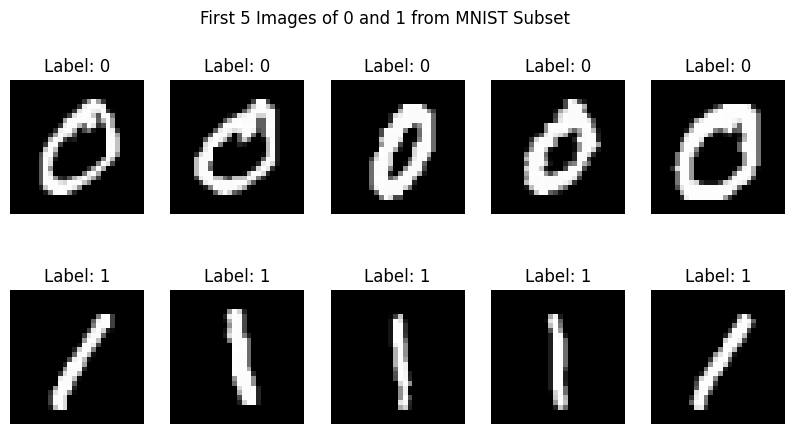

In [11]:
import matplotlib.pyplot as plt

# Separate images for label 0 and label 1
images_0 = X[y == 0]
images_1 = X[y == 1]

# Create subplot
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if enough images exist
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

1. Q3: What does the weights array represent in this context?


*   Stores importance of each pixel (feature)
*   One weight per feature (784 weights)



Q4: Why are we initializing the weights to zero? What effect could this
have on the training process?


*   Simple starting point
*   Allows model to learn from scratch

*   No prior bias in learning






In [3]:
# 4. Implement a Decision Function or Activation Function:
# Decision Function
import numpy as np

def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias

    # Step function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

In [4]:
# Train Perceptron
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        for i in range(len(X)):

            # Linear combination
            output = np.dot(X[i], weights) + bias

            # Step function
            y_pred = 1 if output >= 0 else 0

            # Update if wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    # Final prediction
    predictions = decision_function(X, weights, bias)
    accuracy = np.mean(predictions == y)

    return weights, bias, accuracy

Q5: What is the purpose of the output = np.dot(X[i], weights) + bias line?


*   Computes weighted sum of inputs
*   Used to decide output class



Q6: What happens when the prediction is wrong? How are the weights and
bias updated?


*   Weights are updated:
weights = weights + learning_rate * (y - y_pred) * X[i]
*   Bias is updated:
bias = bias + learning_rate * (y - y_pred)




Q7:Why is the final accuracy important, and what do you expect it to be?


*   Measures model performance
*   Expected: very high (close to 1.0) since 0 and 1 are linearly separable



Final Accuracy: 0.5323


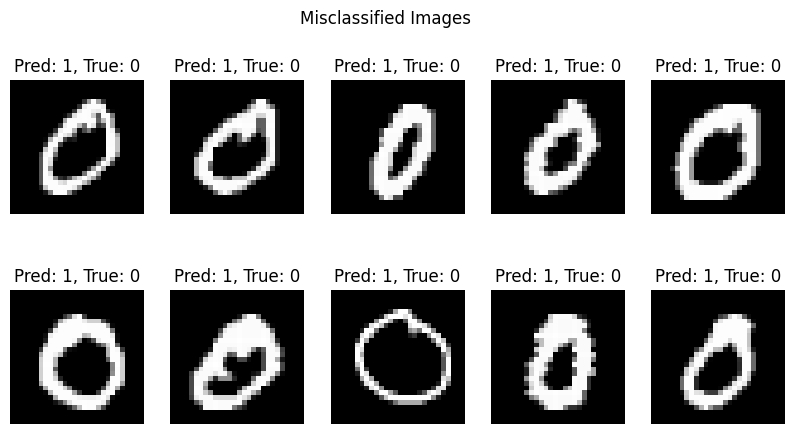

In [13]:
import matplotlib.pyplot as plt

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Find misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

# Visualize misclassified images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Q8:What does misclassified idx store, and how is it used in this code?


*   Stores indices where prediction ≠ actual label
*   Used to display wrong images



Q9: How do you interpret the result if the output is ”All images were
correctly classified!”?


*   Model achieved perfect classification
*   Means dataset is linearly separable and well learned



In [7]:
import pandas as pd
import numpy as np

# Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/Worksheet3/mnist_3_and_5.csv")

# Split features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Initialize
weights = np.zeros(X.shape[1])
bias = 0

# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.0


Final Accuracy: 0.0000


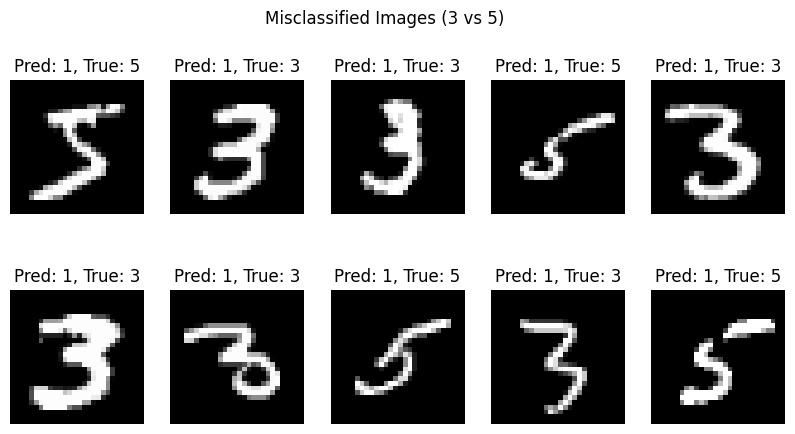

In [8]:
# Task 3 – Misclassified Images Code
# Get predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Find misclassified images
misclassified_idx = np.where(y_pred != y)[0]

# Plot misclassified images
import matplotlib.pyplot as plt

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:


*   The perceptron model was applied to classify digits 3 and 5 from the MNIST dataset.
*   Compared to the 0 vs 1 classification, the accuracy is lower.

*   This is because digits 3 and 5 are more visually similar, making them harder to separate.
*   Several images were misclassified, as seen in the visualization.

*   The perceptron struggles because it creates a linear decision boundary, while this problem is more complex and not perfectly linearly separable.
*   This demonstrates a key limitation of the perceptron model in handling complex image data.





